E-401 HEAT EXCHANGER DESIGN - KERN METHOD

R-402 Python hot-side inlet temperature: 244.476 °C
R-402 Python hot-side inlet pressure: 48.810 bar
Calculated E-401 hot-side outlet temperature: 188.961 °C
Cold-side temperature programme: 40.0 -> 220.0 °C
Heat Duty Q: 1422.00 kW
Cold-side Cp check: 1405.71 kW
LMTD: 68.93 K
Correction Factor Ft: 0.901
Effective Temperature Difference: 62.07 K
Tube Length L: 4.88 m
Shell passes: 2
Tube passes: 4

VELOCITY CONSTRAINTS:
  Tube-side high-pressure vapour: 5.0-10.0 m/s
  Shell-side high-pressure vapour: 5.0-10.0 m/s

DESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS
d_o(m)   d_i(m)   Areq(m²)   Ainst(m²)   N_t    D_s(m)   U         u_t      u_s      dPt      dPs      OK  
---------------------------------------------------------------------------------------------------------
0.016    0.012    48.9       49.1        200    0.419    468.4     31.96    34.50    446.44   442.05   NO  
0.020    0.016    64.8       65.0        212    0.517    353.8     16.96

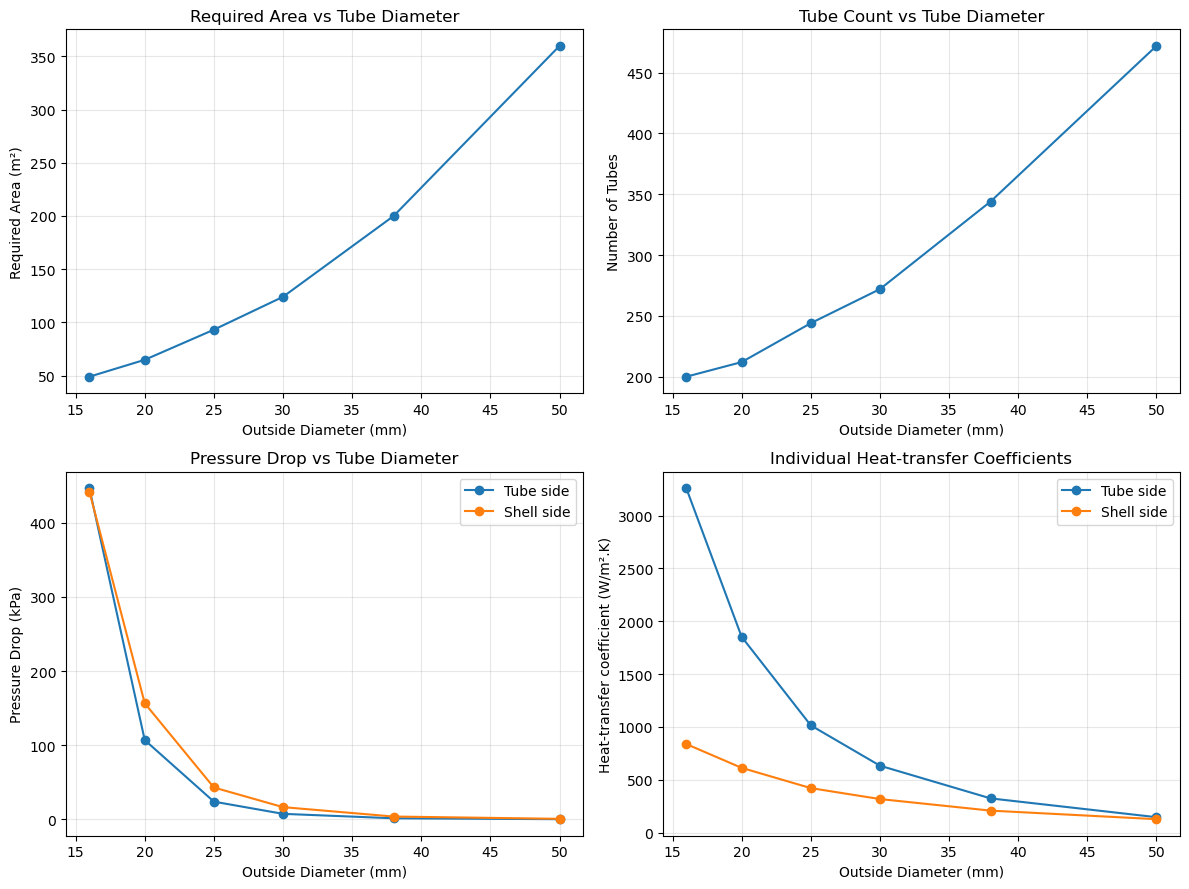


ACCEPTABLE DESIGNS (Meeting ALL Criteria)

Tube OD: 30.0 mm
  Tube ID: 26.0 mm
  Number of tubes: 272
  Tube passes: 4
  Shell passes: 2
  Shell diameter: 0.838 m
  Required area: 123.97 m²
  Installed area: 125.10 m²
  Overall U: 184.8 W/m².K
  Tube-side h: 633.4 W/m².K
  Shell-side h: 317.5 W/m².K
  Tube velocity: 5.01 m/s
  Shell velocity: 8.61 m/s
  Tube pressure drop: 7.40 kPa
  Shell pressure drop: 16.47 kPa
  L/Ds: 5.82

SELECTED E-401 DESIGN
Tube OD: 30.0 mm
Tube ID: 26.0 mm
Number of tubes: 272
Tube length: 4.88 m
Tube passes: 4
Shell passes: 2
Shell diameter: 0.838 m
Required heat-transfer area: 123.97 m²
Installed heat-transfer area: 125.10 m²
Overall heat-transfer coefficient: 184.8 W/m².K
Tube-side velocity: 5.01 m/s
Shell-side velocity: 8.61 m/s
Tube-side pressure drop: 7.40 kPa
Shell-side pressure drop: 16.47 kPa
Hot-side outlet temperature: 188.96 °C
LMTD: 68.93 K
Ft: 0.901

DESIGN COMPLETE


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Implements Kern-type shell-and-tube heat exchanger design for E-401
# Hot side inlet is taken directly from the final R-402 Python model outlet.

# =============================================================================
# INPUT PARAMETERS
# =============================================================================

# Molecular weights [kg/kmol]
MW_values = {
    'H2': 2.01588, 'N2': 28.0134, 'CO': 28.0101, 'CO2': 44.0095,
    'CH4': 16.0425, 'H2O': 18.01528, 'C2H2': 26.0373,
    'C2H4': 28.0532, 'C2H6': 30.069, 'C6H6': 78.1118,
    'CH3OH': 32.04186, 'H2S': 34.0809
}

# Representative gas heat capacities [kJ/kg/K], retained consistently with E-402/E-403
Cp_values = {
    'H2': 14.5, 'N2': 1.05, 'CO': 1.05, 'CO2': 0.98,
    'CH4': 2.69, 'H2O': 1.93, 'C2H2': 2.02,
    'C2H4': 2.05, 'C2H6': 2.37, 'C6H6': 1.61,
    'CH3OH': 1.73, 'H2S': 1.05
}

# -----------------------------------------------------------------------------
# Tube side: fresh clean syngas, Stream 342 -> Stream 401
# -----------------------------------------------------------------------------
cold_mass_flow_kg_h = {
    'H2': 1244.259,
    'N2': 18.857,
    'CO': 8011.277,
    'CO2': 572.267,
    'CH4': 340.545,
    'H2S': 0.009,
    'H2O': 0.0,
    'C2H2': 6.020,
    'C2H4': 73.309,
    'C2H6': 0.314,
    'C6H6': 0.455,
    'CH3OH': 0.0,
}

m_c = sum(cold_mass_flow_kg_h.values()) / 3600.0
Cp_c = (
    sum(cold_mass_flow_kg_h[i] * Cp_values[i] for i in cold_mass_flow_kg_h)
    / sum(cold_mass_flow_kg_h.values())
) * 1000.0

total_kmol_h_c = sum(
    cold_mass_flow_kg_h[i] / MW_values[i]
    for i in cold_mass_flow_kg_h
)
MW_c = sum(cold_mass_flow_kg_h.values()) / total_kmol_h_c

t1 = 40.0       # cold-side inlet temperature, °C
t2 = 220.0      # cold-side outlet target, °C
P_c_bar = 48.963
Z_c = 1.01
T_c_mean_K = ((t1 + t2) / 2.0) + 273.15
rho_c = P_c_bar * 1e5 * (MW_c / 1000.0) / (Z_c * 8.314462618 * T_c_mean_K)
mu_c = 2.3e-5      # Pa.s
k_c = 0.10         # W/m/K
fouling_c = 0.0002 # m2.K/W

# -----------------------------------------------------------------------------
# Shell side: R-402 reactor effluent from final Python model
# -----------------------------------------------------------------------------
hot_mass_flow_kg_h = {
    'H2': 2639.9851464843246,
    'CO': 8093.463185281530,
    'CO2': 4465.339646381825,
    'CH4': 7887.074,
    'N2': 455.726,
    'H2O': 98.74402185233754,
    'CH3OH': 9423.206,
    'C2H2': 78.953,
    'C2H4': 1316.273,
    'C2H6': 5.568,
    'C6H6': 0.509,
}

m_h = sum(hot_mass_flow_kg_h.values()) / 3600.0
Cp_h = (
    sum(hot_mass_flow_kg_h[i] * Cp_values[i] for i in hot_mass_flow_kg_h)
    / sum(hot_mass_flow_kg_h.values())
) * 1000.0

total_kmol_h_h = sum(
    hot_mass_flow_kg_h[i] / MW_values[i]
    for i in hot_mass_flow_kg_h
)
MW_h = sum(hot_mass_flow_kg_h.values()) / total_kmol_h_h

T1 = 244.4755418161709  # R-402 Python outlet temperature, °C
P_h_bar = 48.8101722918890  # R-402 Python outlet pressure, bar
Z_h = 1.02

# E-401 duty retained from the converged Aspen process balance.
Q_design = 1422.0e3  # W

# Calculate hot-side outlet temperature from the R-402 Python inlet state and E-401 duty.
T2 = T1 - Q_design / (m_h * Cp_h)

T_h_mean_K = ((T1 + T2) / 2.0) + 273.15
rho_h = P_h_bar * 1e5 * (MW_h / 1000.0) / (Z_h * 8.314462618 * T_h_mean_K)
mu_h = 2.5e-5      # Pa.s
k_h = 0.12         # W/m/K
fouling_h = 0.0002 # m2.K/W

# Cold-side sensible-duty check; Aspen duty remains the sizing basis.
Q_cold_check = m_c * Cp_c * (t2 - t1)

# =============================================================================
# EXCHANGER CONFIGURATION
# =============================================================================

# The temperature programme contains a temperature cross (cold outlet > hot outlet).
# A single shell pass cannot provide a valid F-factor for this duty.
# Two shell passes and four tube passes are therefore used.
N_shell_passes = 2
N_p = 4

# Tube specifications
d_o_list = [0.016, 0.020, 0.025, 0.030, 0.038, 0.050]  # m
wall_thickness = 0.002   # m
k_w = 45.0               # W/m/K, low-alloy/carbon-steel tube wall approximation
L = 4.88                  # m
pitch_ratio = 1.25        # triangular pitch

# Design parameters
U_assumed = 200.0         # W/m2/K, initial gas-gas estimate only
baffle_spacing_ratio = 1.0

# Allowable pressure drops: 10% of available gauge pressure
system_gauge_pressure_tube_bar = P_c_bar - 1.01325
system_gauge_pressure_shell_bar = P_h_bar - 1.01325
deltaP_tube_max = 0.10 * system_gauge_pressure_tube_bar * 1e5
deltaP_shell_max = 0.10 * system_gauge_pressure_shell_bar * 1e5

# Velocity constraints for high-pressure vapour on both sides
v_tube_min = 5.0
v_tube_max = 10.0
v_shell_min = 5.0
v_shell_max = 10.0

# =============================================================================
# HEAT TRANSFER CALCULATIONS
# =============================================================================

def calculate_heat_duty():
    """Use Aspen E-401 duty as the process design basis."""
    return Q_design


def calculate_LMTD(T1, T2, t1, t2):
    """Counter-current log-mean temperature difference."""
    delta_T1 = T1 - t2
    delta_T2 = T2 - t1

    if delta_T1 <= 0 or delta_T2 <= 0:
        raise ValueError('Non-positive terminal temperature difference.')

    if abs(delta_T1 - delta_T2) < 1e-9:
        return delta_T1

    return (delta_T2 - delta_T1) / math.log(delta_T2 / delta_T1)


def calculate_Ft_multi_shell(T1, T2, t1, t2, N_shell):
    """
    LMTD correction factor for N shell passes with an even number of tube passes.
    Uses the standard multi-shell-pass analytical form based on R and P.
    """
    R = (T1 - T2) / (t2 - t1)
    P = (t2 - t1) / (T1 - t1)

    if abs(R - 1.0) < 1e-8:
        R = 1.00000001

    root = math.sqrt(R**2 + 1.0)
    S = root / (R - 1.0)

    base = (1.0 - P * R) / (1.0 - P)
    if base <= 0:
        raise ValueError('Invalid temperature programme for F-factor calculation.')

    W = base ** (1.0 / N_shell)
    numerator_arg = 1.0 + W - S + S * W
    denominator_arg = 1.0 + W + S - S * W

    if numerator_arg <= 0 or denominator_arg <= 0:
        raise ValueError('Selected number of shell passes does not give a valid F-factor.')

    denominator = math.log(numerator_arg / denominator_arg)
    if abs(denominator) < 1e-12:
        return 1.0

    Ft = S * math.log(W) / denominator
    return Ft

# =============================================================================
# TUBE BUNDLE GEOMETRY
# =============================================================================

def calculate_tube_count(A_req, d_o, L):
    """Calculate number of tubes and round to a multiple of tube passes."""
    N_t = int(math.ceil(A_req / (math.pi * d_o * L)))
    remainder = N_t % N_p
    if remainder != 0:
        N_t += N_p - remainder
    return N_t


def calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p):
    """Tube bundle diameter from standard tube-count constants."""
    constants = {
        1: (0.319, 2.142),
        2: (0.249, 2.207),
        4: (0.175, 2.285),
        6: (0.0743, 2.499),
    }
    K1, n1 = constants.get(N_p, (0.175, 2.285))
    return d_o * (N_t / K1) ** (1.0 / n1)


def calculate_shell_diameter(D_b):
    """Estimate shell diameter from bundle diameter and clearance."""
    if D_b < 0.3:
        clearance = 0.05
    elif D_b < 0.5:
        clearance = 0.07
    elif D_b < 1.0:
        clearance = 0.09
    else:
        clearance = 0.11
    return D_b + clearance

# =============================================================================
# TUBE SIDE CALCULATIONS
# =============================================================================

def tube_side_coefficient(d_i, N_t, N_p, m, rho, mu, k, Cp):
    """Tube-side gas heat-transfer coefficient."""
    A_t = (N_t / N_p) * math.pi * d_i**2 / 4.0
    u_t = m / (rho * A_t)
    Re = rho * u_t * d_i / mu
    Pr = Cp * mu / k

    if Re > 2100:
        Nu = 0.021 * Re**0.8 * Pr**0.33
    else:
        Nu = 3.66

    h_t = Nu * k / d_i
    return h_t, Re, u_t


def tube_side_pressure_drop(N_p, L, d_i, rho, u_t, Re):
    """Tube-side pressure drop including return losses."""
    if Re > 2100:
        jf = 0.079 * Re**(-0.25)
    else:
        jf = 16.0 / Re

    return N_p * (8.0 * jf * (L / d_i) + 2.5) * (rho * u_t**2 / 2.0)

# =============================================================================
# SHELL SIDE CALCULATIONS
# =============================================================================

def shell_side_equivalent_diameter(d_o, pitch_ratio):
    """Equivalent shell-side diameter for triangular tube pitch."""
    p_t = pitch_ratio * d_o
    return (1.10 / d_o) * (p_t**2 - 0.917 * d_o**2)


def shell_side_coefficient(D_s, d_o, d_e, baffle_spacing_ratio,
                           m, rho, mu, k, Cp, N_shell):
    """
    Kern-type shell-side gas coefficient.
    For the two-shell-pass arrangement the available cross-flow area is
    approximated as half the full-shell area per shell pass.
    """
    l_B = baffle_spacing_ratio * D_s
    p_t = pitch_ratio * d_o

    A_s_full = (p_t - d_o) * D_s * l_B / p_t
    A_s = A_s_full / N_shell

    u_s = m / (rho * A_s)
    Re = rho * u_s * d_e / mu
    Pr = Cp * mu / k

    jh = 0.36 * Re**(-0.55)
    Nu = jh * Re * Pr**(1.0 / 3.0)
    h_s = Nu * k / d_e

    return h_s, Re, u_s, l_B


def shell_side_pressure_drop(D_s, d_e, L, l_B, rho, u_s, Re, N_shell):
    """Approximate shell-side pressure drop over all shell passes."""
    if Re < 1000:
        jf = 0.44 * Re**(-0.15)
    else:
        jf = 0.044 * Re**(-0.15)

    N_b = L / l_B
    deltaP_one_pass = (
        8.0 * jf
        * (D_s / d_e)
        * N_b
        * (rho * u_s**2 / 2.0)
    )

    return N_shell * deltaP_one_pass

# =============================================================================
# OVERALL HEAT TRANSFER COEFFICIENT
# =============================================================================

def calculate_overall_U(h_t, h_s, d_o, d_i, k_w, fouling_t, fouling_s):
    """Overall heat-transfer coefficient based on outside tube area."""
    U_inv = (
        1.0 / h_s
        + fouling_s
        + d_o * math.log(d_o / d_i) / (2.0 * k_w)
        + (d_o * fouling_t) / d_i
        + d_o / (d_i * h_t)
    )
    return 1.0 / U_inv

# =============================================================================
# MAIN DESIGN ITERATION
# =============================================================================

Q = calculate_heat_duty()
LMTD = calculate_LMTD(T1, T2, t1, t2)
Ft = calculate_Ft_multi_shell(T1, T2, t1, t2, N_shell_passes)
deltaT_m = Ft * LMTD

print('=' * 80)
print('E-401 HEAT EXCHANGER DESIGN - KERN METHOD')
print('=' * 80)
print(f'\nR-402 Python hot-side inlet temperature: {T1:.3f} °C')
print(f'R-402 Python hot-side inlet pressure: {P_h_bar:.3f} bar')
print(f'Calculated E-401 hot-side outlet temperature: {T2:.3f} °C')
print(f'Cold-side temperature programme: {t1:.1f} -> {t2:.1f} °C')
print(f'Heat Duty Q: {Q / 1000:.2f} kW')
print(f'Cold-side Cp check: {Q_cold_check / 1000:.2f} kW')
print(f'LMTD: {LMTD:.2f} K')
print(f'Correction Factor Ft: {Ft:.3f}')
print(f'Effective Temperature Difference: {deltaT_m:.2f} K')
print(f'Tube Length L: {L:.2f} m')
print(f'Shell passes: {N_shell_passes}')
print(f'Tube passes: {N_p}')

if Ft < 0.75:
    print('WARNING: Ft < 0.75; exchanger configuration should be reconsidered.')

print('\n' + '=' * 80)
print('VELOCITY CONSTRAINTS:')
print(f'  Tube-side high-pressure vapour: {v_tube_min}-{v_tube_max} m/s')
print(f'  Shell-side high-pressure vapour: {v_shell_min}-{v_shell_max} m/s')
print('=' * 80)

results = []

for d_o in d_o_list:
    d_i = d_o - 2.0 * wall_thickness

    if d_i <= 0:
        continue

    U_calc = U_assumed
    tolerance = 0.01
    max_iterations = 50

    for iteration in range(max_iterations):
        A_req = Q / (U_calc * deltaT_m)
        N_t = calculate_tube_count(A_req, d_o, L)
        D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
        D_s = calculate_shell_diameter(D_b)
        A_inst = N_t * math.pi * d_o * L

        h_t, Re_t, u_t = tube_side_coefficient(
            d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c
        )
        deltaP_t = tube_side_pressure_drop(
            N_p, L, d_i, rho_c, u_t, Re_t
        )

        d_e = shell_side_equivalent_diameter(d_o, pitch_ratio)
        h_s, Re_s, u_s, l_B = shell_side_coefficient(
            D_s, d_o, d_e, baffle_spacing_ratio,
            m_h, rho_h, mu_h, k_h, Cp_h, N_shell_passes
        )
        deltaP_s = shell_side_pressure_drop(
            D_s, d_e, L, l_B, rho_h, u_s, Re_s, N_shell_passes
        )

        U_new = calculate_overall_U(
            h_t, h_s, d_o, d_i, k_w, fouling_c, fouling_h
        )

        if abs(U_new - U_calc) / U_calc < tolerance:
            U_calc = U_new
            break

        U_calc = U_new

    A_req = Q / (U_calc * deltaT_m)
    N_t = calculate_tube_count(A_req, d_o, L)
    D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
    D_s = calculate_shell_diameter(D_b)
    A_inst = N_t * math.pi * d_o * L

    h_t, Re_t, u_t = tube_side_coefficient(
        d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c
    )
    deltaP_t = tube_side_pressure_drop(
        N_p, L, d_i, rho_c, u_t, Re_t
    )

    d_e = shell_side_equivalent_diameter(d_o, pitch_ratio)
    h_s, Re_s, u_s, l_B = shell_side_coefficient(
        D_s, d_o, d_e, baffle_spacing_ratio,
        m_h, rho_h, mu_h, k_h, Cp_h, N_shell_passes
    )
    deltaP_s = shell_side_pressure_drop(
        D_s, d_e, L, l_B, rho_h, u_s, Re_s, N_shell_passes
    )

    v_tube_ok = v_tube_min <= u_t <= v_tube_max
    v_shell_ok = v_shell_min <= u_s <= v_shell_max
    velocity_ok = v_tube_ok and v_shell_ok

    L_over_D = L / D_s
    geometry_ok = 5.0 <= L_over_D <= 10.0

    pressure_ok = (
        deltaP_t < deltaP_tube_max
        and deltaP_s < deltaP_shell_max
    )

    results.append({
        'd_o': d_o,
        'd_i': d_i,
        'A_req': A_req,
        'A_inst': A_inst,
        'N_t': N_t,
        'D_s': D_s,
        'h_t': h_t,
        'h_s': h_s,
        'U': U_calc,
        'deltaP_t': deltaP_t / 1000.0,
        'deltaP_s': deltaP_s / 1000.0,
        'Re_t': Re_t,
        'Re_s': Re_s,
        'u_t': u_t,
        'u_s': u_s,
        'L_over_D': L_over_D,
        'v_tube_ok': v_tube_ok,
        'v_shell_ok': v_shell_ok,
        'velocity_ok': velocity_ok,
        'pressure_ok': pressure_ok,
        'geometry_ok': geometry_ok,
    })

# =============================================================================
# RESULTS
# =============================================================================

print('\nDESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS')
print('=' * 105)
print(
    f"{'d_o(m)':<8} {'d_i(m)':<8} {'Areq(m²)':<10} {'Ainst(m²)':<11} {'N_t':<6} "
    f"{'D_s(m)':<8} {'U':<9} {'u_t':<8} {'u_s':<8} {'dPt':<8} {'dPs':<8} {'OK':<4}"
)
print('-' * 105)

for r in results:
    overall_ok = r['velocity_ok'] and r['pressure_ok'] and r['geometry_ok']
    print(
        f"{r['d_o']:<8.3f} {r['d_i']:<8.3f} {r['A_req']:<10.1f} {r['A_inst']:<11.1f} "
        f"{r['N_t']:<6d} {r['D_s']:<8.3f} {r['U']:<9.1f} {r['u_t']:<8.2f} "
        f"{r['u_s']:<8.2f} {r['deltaP_t']:<8.2f} {r['deltaP_s']:<8.2f} "
        f"{'YES' if overall_ok else 'NO':<4}"
    )

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
d_o_mm = [r['d_o'] * 1000.0 for r in results]

axes[0, 0].plot(d_o_mm, [r['A_req'] for r in results], marker='o')
axes[0, 0].set_xlabel('Outside Diameter (mm)')
axes[0, 0].set_ylabel('Required Area (m²)')
axes[0, 0].set_title('Required Area vs Tube Diameter')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(d_o_mm, [r['N_t'] for r in results], marker='o')
axes[0, 1].set_xlabel('Outside Diameter (mm)')
axes[0, 1].set_ylabel('Number of Tubes')
axes[0, 1].set_title('Tube Count vs Tube Diameter')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(d_o_mm, [r['deltaP_t'] for r in results], marker='o', label='Tube side')
axes[1, 0].plot(d_o_mm, [r['deltaP_s'] for r in results], marker='o', label='Shell side')
axes[1, 0].set_xlabel('Outside Diameter (mm)')
axes[1, 0].set_ylabel('Pressure Drop (kPa)')
axes[1, 0].set_title('Pressure Drop vs Tube Diameter')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(d_o_mm, [r['h_t'] for r in results], marker='o', label='Tube side')
axes[1, 1].plot(d_o_mm, [r['h_s'] for r in results], marker='o', label='Shell side')
axes[1, 1].set_xlabel('Outside Diameter (mm)')
axes[1, 1].set_ylabel('Heat-transfer coefficient (W/m².K)')
axes[1, 1].set_title('Individual Heat-transfer Coefficients')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

acceptable_designs = [
    r for r in results
    if r['velocity_ok'] and r['pressure_ok'] and r['geometry_ok']
]

if acceptable_designs:
    print('\n' + '=' * 80)
    print('ACCEPTABLE DESIGNS (Meeting ALL Criteria)')
    print('=' * 80)

    for r in acceptable_designs:
        print(f"\nTube OD: {r['d_o'] * 1000:.1f} mm")
        print(f"  Tube ID: {r['d_i'] * 1000:.1f} mm")
        print(f"  Number of tubes: {r['N_t']}")
        print(f"  Tube passes: {N_p}")
        print(f"  Shell passes: {N_shell_passes}")
        print(f"  Shell diameter: {r['D_s']:.3f} m")
        print(f"  Required area: {r['A_req']:.2f} m²")
        print(f"  Installed area: {r['A_inst']:.2f} m²")
        print(f"  Overall U: {r['U']:.1f} W/m².K")
        print(f"  Tube-side h: {r['h_t']:.1f} W/m².K")
        print(f"  Shell-side h: {r['h_s']:.1f} W/m².K")
        print(f"  Tube velocity: {r['u_t']:.2f} m/s")
        print(f"  Shell velocity: {r['u_s']:.2f} m/s")
        print(f"  Tube pressure drop: {r['deltaP_t']:.2f} kPa")
        print(f"  Shell pressure drop: {r['deltaP_s']:.2f} kPa")
        print(f"  L/Ds: {r['L_over_D']:.2f}")
else:
    print('\n' + '=' * 80)
    print('WARNING: No designs meet ALL criteria.')
    print('=' * 80)

# Select the acceptable design with the smallest required area.
selected_design = min(acceptable_designs, key=lambda r: r['A_req']) if acceptable_designs else None

if selected_design is not None:
    r = selected_design
    print('\n' + '=' * 80)
    print('SELECTED E-401 DESIGN')
    print('=' * 80)
    print(f"Tube OD: {r['d_o'] * 1000:.1f} mm")
    print(f"Tube ID: {r['d_i'] * 1000:.1f} mm")
    print(f"Number of tubes: {r['N_t']}")
    print(f"Tube length: {L:.2f} m")
    print(f"Tube passes: {N_p}")
    print(f"Shell passes: {N_shell_passes}")
    print(f"Shell diameter: {r['D_s']:.3f} m")
    print(f"Required heat-transfer area: {r['A_req']:.2f} m²")
    print(f"Installed heat-transfer area: {r['A_inst']:.2f} m²")
    print(f"Overall heat-transfer coefficient: {r['U']:.1f} W/m².K")
    print(f"Tube-side velocity: {r['u_t']:.2f} m/s")
    print(f"Shell-side velocity: {r['u_s']:.2f} m/s")
    print(f"Tube-side pressure drop: {r['deltaP_t']:.2f} kPa")
    print(f"Shell-side pressure drop: {r['deltaP_s']:.2f} kPa")
    print(f"Hot-side outlet temperature: {T2:.2f} °C")
    print(f"LMTD: {LMTD:.2f} K")
    print(f"Ft: {Ft:.3f}")

print('\n' + '=' * 80)
print('DESIGN COMPLETE')
print('=' * 80)
